# CSAPS

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [3]:
from csaps import csaps

https://csaps.readthedocs.io/en/latest/manual.html

## Univariate Data Smoothing

In [5]:
def univariate_data(n=25, seed=1234):
    np.random.seed(seed)
    x = np.linspace(-5., 5., n)
    y = np.exp(-(x/2.5)**2) + (np.random.rand(n) - 0.2) * 0.3
    return x, y

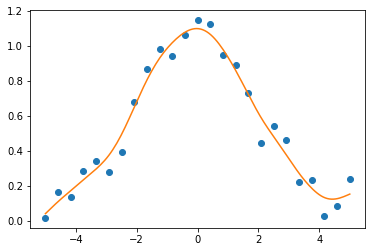

In [6]:
x, y = univariate_data()  # generate univariate sample data (x,y)
xi = np.linspace(x[0], x[-1], 150)  # generates 

yi = csaps(x, y, xi, smooth=0.85)  # generaytes the smoothing at the xi points

plt.plot(x, y, 'o', xi, yi, '-')

## Mutivariate Smoothing

In [7]:
# data sites
x = [1, 2, 3, 4]

# 3 data vectors (3-D)
y = [
    (2, 4, 6, 8),
    (1, 3, 5, 7),
    (5, 1, 3, 9),
]

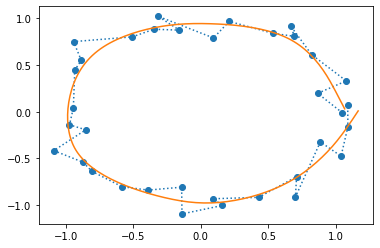

In [9]:
np.random.seed(1234)  # initializes the random generator
theta = np.linspace(0, 2*np.pi, 35)  # generates 35 points between 0 and 2*pi
x = np.cos(theta) + np.random.randn(35) * 0.1  # shifts the theta points randomly to generate x
y = np.sin(theta) + np.random.randn(35) * 0.1  # shifts the theta points randomly to generate y 
data = [x, y]  # builds the sample set
theta_i = np.linspace(0, 2*np.pi, 200)  # generates a second set of pints between 0 adn 2*pi

data_i = csaps(theta, data, theta_i, smooth=0.95) # find the smoothing for the points
xi = data_i[0, :]
yi = data_i[1, :]

plt.plot(x, y, ':o', xi, yi, '-')

## 3-D Data Smoothing

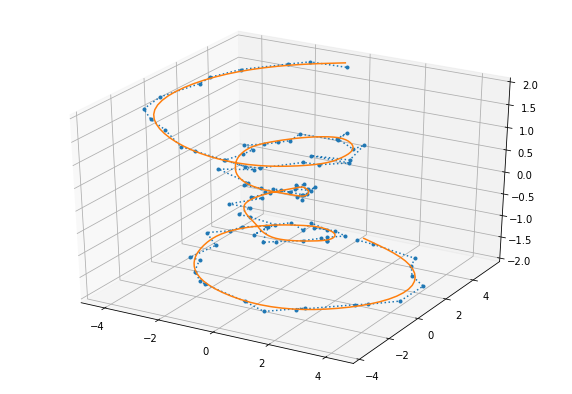

In [11]:
np.random.seed(1234)
n = 100
theta = np.linspace(-4 * np.pi, 4 * np.pi, n)
z = np.linspace(-2, 2, n)
r = z ** 2 + 1
x = r * np.sin(theta) + np.random.randn(n) * 0.3
y = r * np.cos(theta) + np.random.randn(n) * 0.3
data = [x, y, z]
theta_i = np.linspace(-4 * np.pi, 4 * np.pi, 250)

data_i = csaps(theta, data, theta_i, smooth=0.95)
xi = data_i[0, :]
yi = data_i[1, :]
zi = data_i[2, :]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('none')
ax.plot(x, y, z, '.:')
ax.plot(xi, yi, zi, '-')

## ND Grid Smoothing

In [12]:
x = [
    (-2, -1, 0, 1, 2),    # X-grid data sites
    (-2, -1, 0, 1, 2),    # Y-grid data sites
    (-2, -1, 0, 1, 2),    # Z-grid data sites
]

y = np.random.rand(5, 5, 5)  # 5x5x5 3-D grid data values

In [13]:
smooth = [
    0.95,  # the smoothing parameter for X
    0.83,  # the smoothing parameter for Y
    0.51,  # the smoothing parameter for Z
]

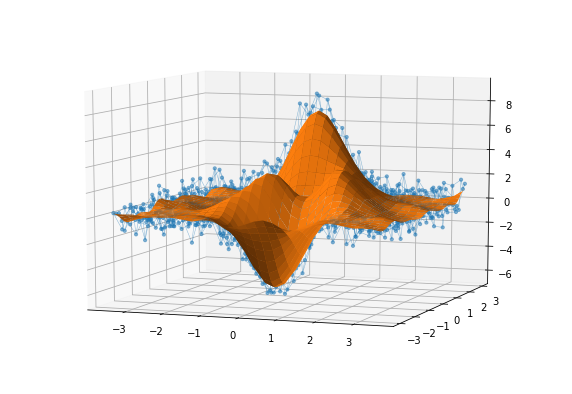

In [15]:
np.random.seed(1234)
xdata = [np.linspace(-3, 3, 41), np.linspace(-3.5, 3.5, 31)]
i, j = np.meshgrid(*xdata, indexing='ij')
ydata = (3 * (1 - j)**2. * np.exp(-(j**2) - (i + 1)**2)
         - 10 * (j / 5 - j**3 - i**5) * np.exp(-j**2 - i**2)
         - 1 / 3 * np.exp(-(j + 1)**2 - i**2))
ydata = ydata + (np.random.randn(*ydata.shape) * 0.75)

ydata_s = csaps(xdata, ydata, xdata, smooth=0.988)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('none')
c = [s['color'] for s in plt.rcParams['axes.prop_cycle']]
ax.plot_wireframe(j, i, ydata, linewidths=0.5, color=c[0], alpha=0.5)
ax.scatter(j, i, ydata, s=10, c=c[0], alpha=0.5)
ax.plot_surface(j, i, ydata_s, color=c[1], linewidth=0, alpha=1.0)
ax.view_init(elev=9., azim=290)

### Automatic Smoothing

0.9920265356892263


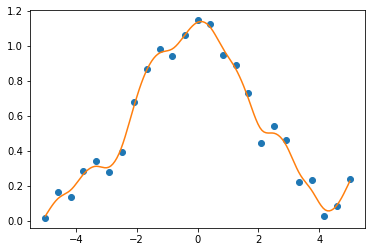

In [17]:
x, y = univariate_data()  # generate univariate sample data (x,y)
xi = np.linspace(x[0], x[-1], 150)  # generates 

yi, smooth = csaps(x, y, xi)  # generaytes the smoothing at the xi points
print(smooth)
plt.plot(x, y, 'o', xi, yi, '-')